Exploratory Data Analysis

----------------------------------------------------------------------------------------------------

Airbnb en Nueva York
Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

----------------------------------------------------------------------------------------------------

importasmos librerias

In [126]:
import pandas as pd 
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import requests
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle



plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)  


Guardar la data

In [81]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv"
response = requests.get(url)

os.makedirs("./data/raw", exist_ok=True)
with open("./data/raw/AB_NYC_2019.csv", "wb") as f:
    f.write(response.content)

Paso 1: Carga del conjunto de datos

In [82]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [83]:
df.shape

(48895, 16)

In [84]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [85]:
df.dtypes

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [86]:
df.describe

<bound method NDFrame.describe of              id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

     

Data preparation


In [87]:
df[['id',# 'name', 'host_id', 'host_name',
     'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews',# 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']]

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,3831,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,36485057,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,36485431,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,36485609,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


In [88]:
#df.drop(["latitude"], axis = 1)

In [89]:
df = df[['id',# 'name', 'host_id', 'host_name',
     'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews',# 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']].copy()

In [90]:
df.shape

(48895, 12)

In [91]:
df.dtypes

id                                  int64
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [92]:
df.rename(columns= {"availability_365": "Yearly_availability" })

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,Yearly_availability
0,2539,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,3831,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,36485057,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,36485431,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,36485609,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


In [93]:
df = df.rename(columns= {"availability_365": "Yearly_availability" })

In [94]:
df.head()

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,Yearly_availability
0,2539,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,3831,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [95]:
df.isna().sum()

id                                    0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
Yearly_availability                   0
dtype: int64

In [96]:
df.loc[df.duplicated()]

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,Yearly_availability


In [97]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
48890    False
48891    False
48892    False
48893    False
48894    False
Length: 48895, dtype: bool

In [98]:
df.loc[df.duplicated(subset=["neighbourhood_group"])].head(5)

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,Yearly_availability
2,3647,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,3831,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
5,5099,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129
6,5121,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,0.40,1,0


In [99]:
df.query("neighbourhood_group == 'Manhattan'")

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,Yearly_availability
1,2595,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
4,5022,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
5,5099,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129
7,5178,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,3.47,1,220
...,...,...,...,...,...,...,...,...,...,...,...,...
48886,36483010,Manhattan,Midtown,40.75561,-73.96723,Entire home/apt,200,6,0,NaN,1,176
48888,36484087,Manhattan,Hell's Kitchen,40.76392,-73.99183,Private room,125,4,0,NaN,1,31
48892,36485431,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,36485609,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


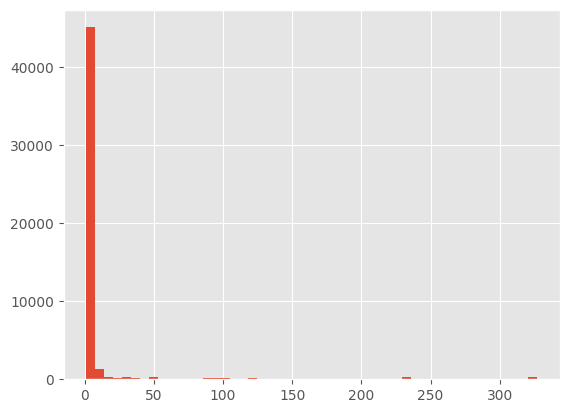

In [100]:
# 1. Ver la distribución primero
df["calculated_host_listings_count"].describe()
df["calculated_host_listings_count"].value_counts().head(10)

# 2. Usar la mediana como corte
median = df["calculated_host_listings_count"].median()
df["host_type"] = df["calculated_host_listings_count"].apply(
    lambda x: "professional" if x > median else "casual"
)

# 3. Ver un histograma para decidir visualmente
df["calculated_host_listings_count"].hist(bins=50)
plt.show()

Dsitribucion extremadamente sesgada a la derecha dado que la amyorias de los Hosts tienen entre 1 a 5 propiedades. Tambein vemos outliers extremos luego del numero 50 como por eje,plo en 100, 200-250 y luego arriba de los 300. 

In [101]:
print(df["calculated_host_listings_count"].describe())
print("\nValores más comunes:")
print(df["calculated_host_listings_count"].value_counts().head(10))

count    48895.000000
mean         7.143982
std         32.952519
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

Valores más comunes:
calculated_host_listings_count
1      32303
2       6658
3       2853
4       1440
5        845
6        570
8        416
7        399
327      327
9        234
Name: count, dtype: int64


La media era 7.14 pero la mediana era 1 — estos outliers la jalan hacia arriba

In [102]:
def classify_host(x):
    if x == 1:
        return "single"        
    elif x <= 5:
        return "casual"       
    else:
        return "professional"  

df["host_type"] = df["calculated_host_listings_count"].apply(classify_host)

print(df["host_type"].value_counts())

print(df.groupby("host_type")["price"].mean())

host_type
single          32303
casual          11796
professional     4796
Name: count, dtype: int64
host_type
casual          124.958715
professional    180.879900
single          158.677677
Name: price, dtype: float64


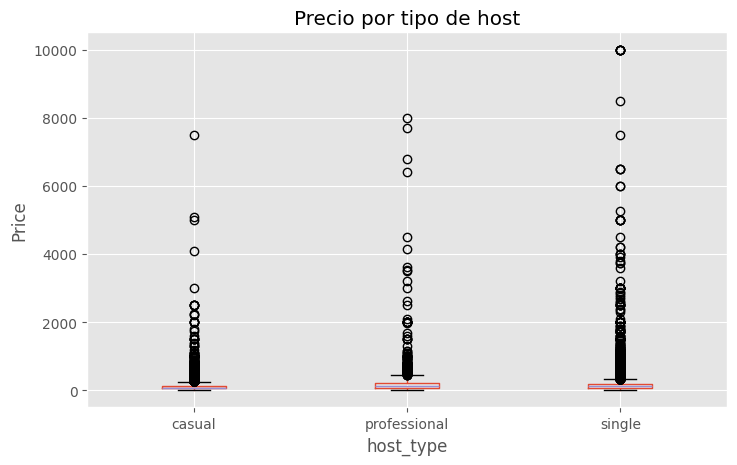

In [103]:
# Boxplot 
df.boxplot(column="price", by="host_type", figsize=(8, 5))
plt.title("Precio por tipo de host")
plt.suptitle("")
plt.ylabel("Price")
plt.show()


nuestas cajas se ven aplastadas dado a los varios outliers. 


In [104]:
#los precios extremos
df[df["price"] > 2000][["neighbourhood_group", "room_type", "price", "host_type"]].sort_values("price", ascending=False).head(10)

,neighbourhood_group,room_type,price,host_type
9151,Queens,Private room,10000,single
17692,Brooklyn,Entire home/apt,10000,single
29238,Manhattan,Entire home/apt,10000,single
40433,Manhattan,Entire home/apt,9999,single
12342,Manhattan,Private room,9999,single
6530,Manhattan,Entire home/apt,9999,single
30268,Manhattan,Entire home/apt,8500,single
4377,Brooklyn,Entire home/apt,8000,professional
29662,Manhattan,Entire home/apt,7703,professional
42523,Manhattan,Entire home/apt,7500,single


Precios repetidos como $10,000 y $9,999. Porbablemnte el sistema pone un precio max de 10.000.
Tambien tenemos sin sentidos. una Private room	por el precio de 9999 no parece ser un dato realista. 

Tambie  Hosts con 1 sola propiedad poniendo precios absurdos,  probablemente listings abandonados o creados como prueba

In [105]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

print(f"Precio máximo permitido: ${upper_limit:.2f}")
print(f"Filas originales: {len(df)}")

df = df[df["price"] <= upper_limit]
print(f"Filas después de limpiar: {len(df)}")

Precio máximo permitido: $334.00
Filas originales: 48895
Filas después de limpiar: 45923


In [106]:
print(f"Listings con precio $0: {(df['price'] == 0).sum()}")
df = df[df["price"] > 0]

Listings con precio $0: 11


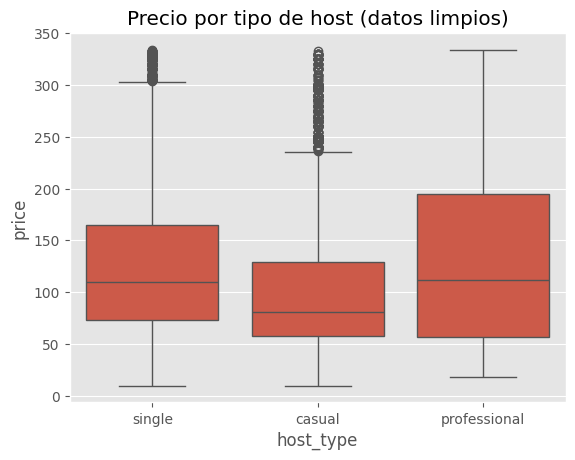

In [107]:
sns.boxplot(data=df, x="host_type", y="price",
            order=["single", "casual", "professional"])
plt.title("Precio por tipo de host (datos limpios)")
plt.show()

Casual cobra menos de la mediana, tineen precios mas consistentes y bajos. 
single y professional tienen medianas similares
professional gestionan propiedades de distintos rangos, desde económicas hasta premium

Conclusion : Ser professional no garantiza cobrar más, pero sí hay más dispersión en sus precios. El tipo de propiedad (room_type) y el barrio probablemente explican más la variación de precio que el tipo de host.

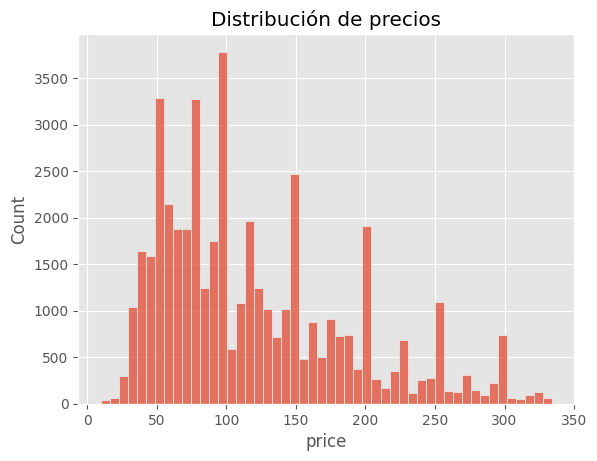

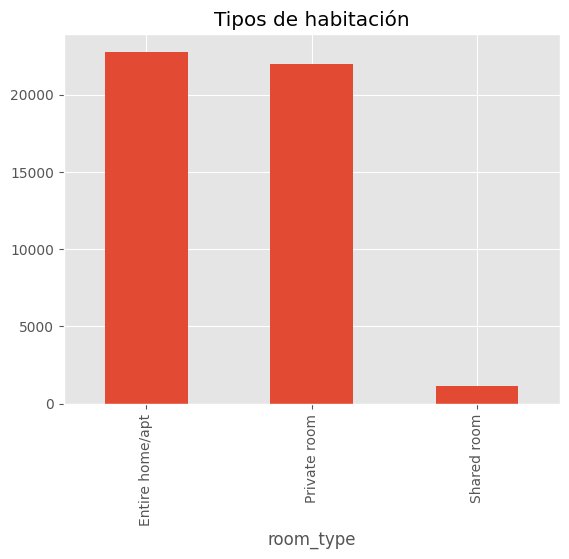

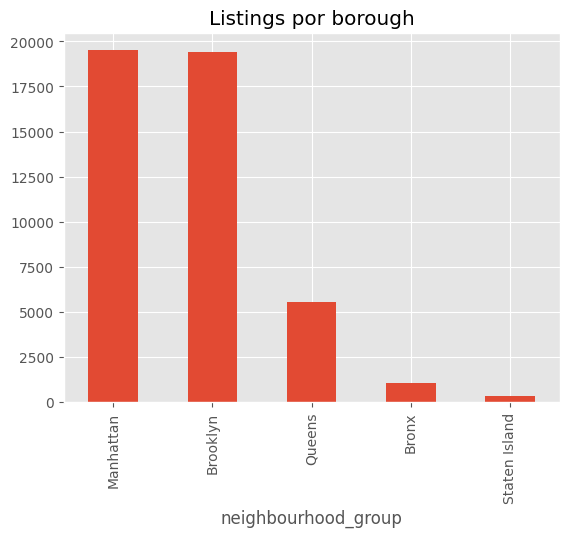

In [108]:
# Distribución de precio
sns.histplot(df["price"], bins=50)
plt.title("Distribución de precios")
plt.show()

# Conteo de room_type
df["room_type"].value_counts().plot(kind="bar")
plt.title("Tipos de habitación")
plt.show()

# Conteo por barrio
df["neighbourhood_group"].value_counts().plot(kind="bar")
plt.title("Listings por borough")
plt.show()

<Axes: >

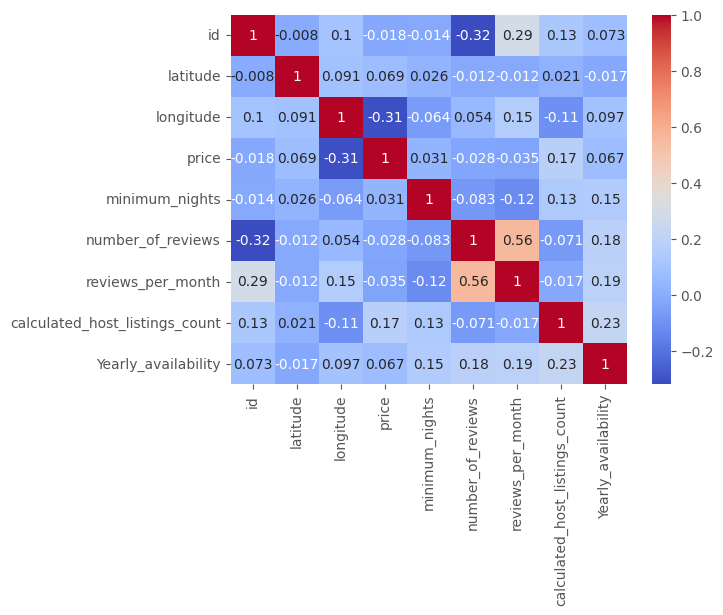

In [109]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

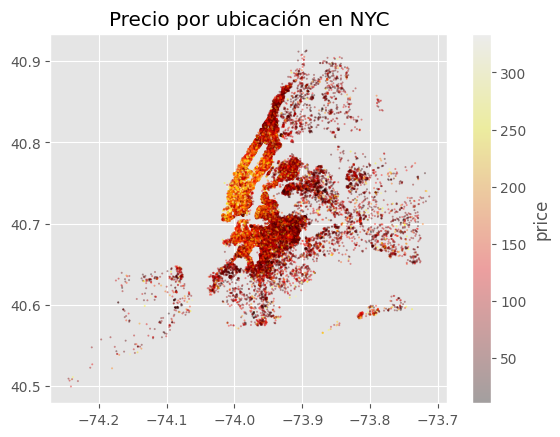

In [110]:
plt.scatter(df["longitude"], df["latitude"], 
            c=df["price"], cmap="hot", alpha=0.3, s=1)
plt.colorbar(label="price")
plt.title("Precio por ubicación en NYC")
plt.show()

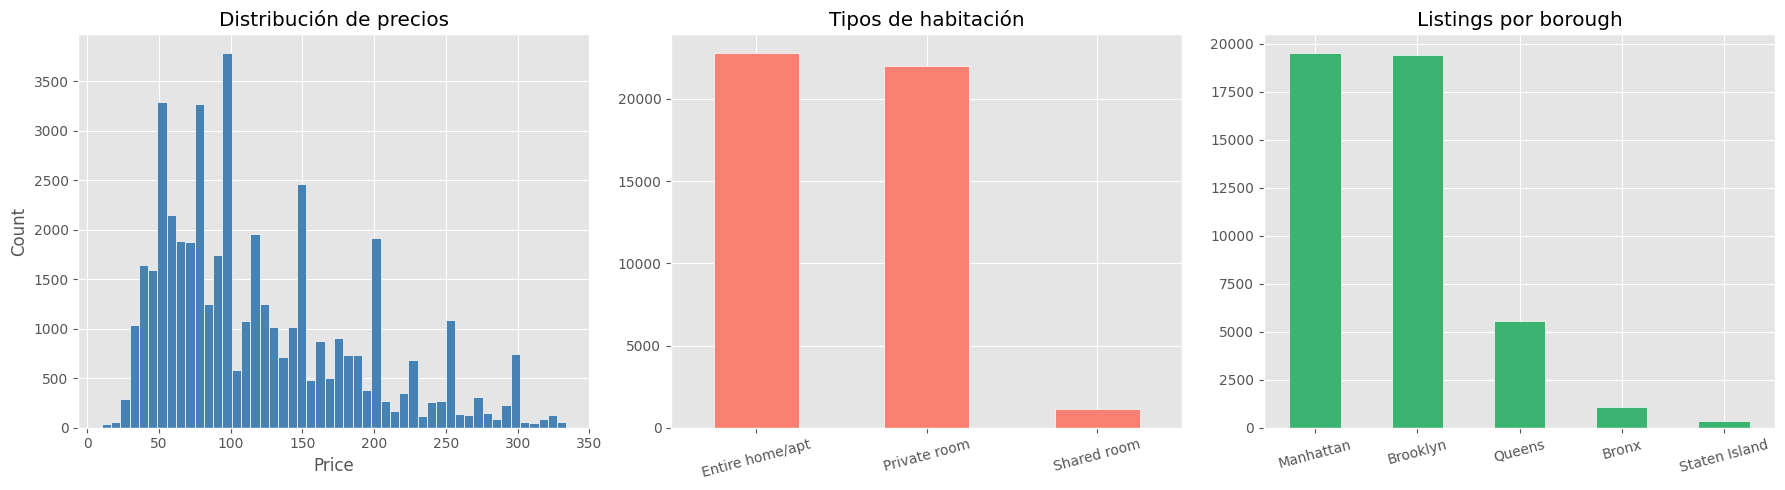

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de precio
axes[0].hist(df["price"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de precios")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

# Conteo de room_type
df["room_type"].value_counts().plot(kind="bar", ax=axes[1], color="salmon", edgecolor="white")
axes[1].set_title("Tipos de habitación")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=15)

# Conteo por borough
df["neighbourhood_group"].value_counts().plot(kind="bar", ax=axes[2], color="mediumseagreen", edgecolor="white")
axes[2].set_title("Listings por borough")
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

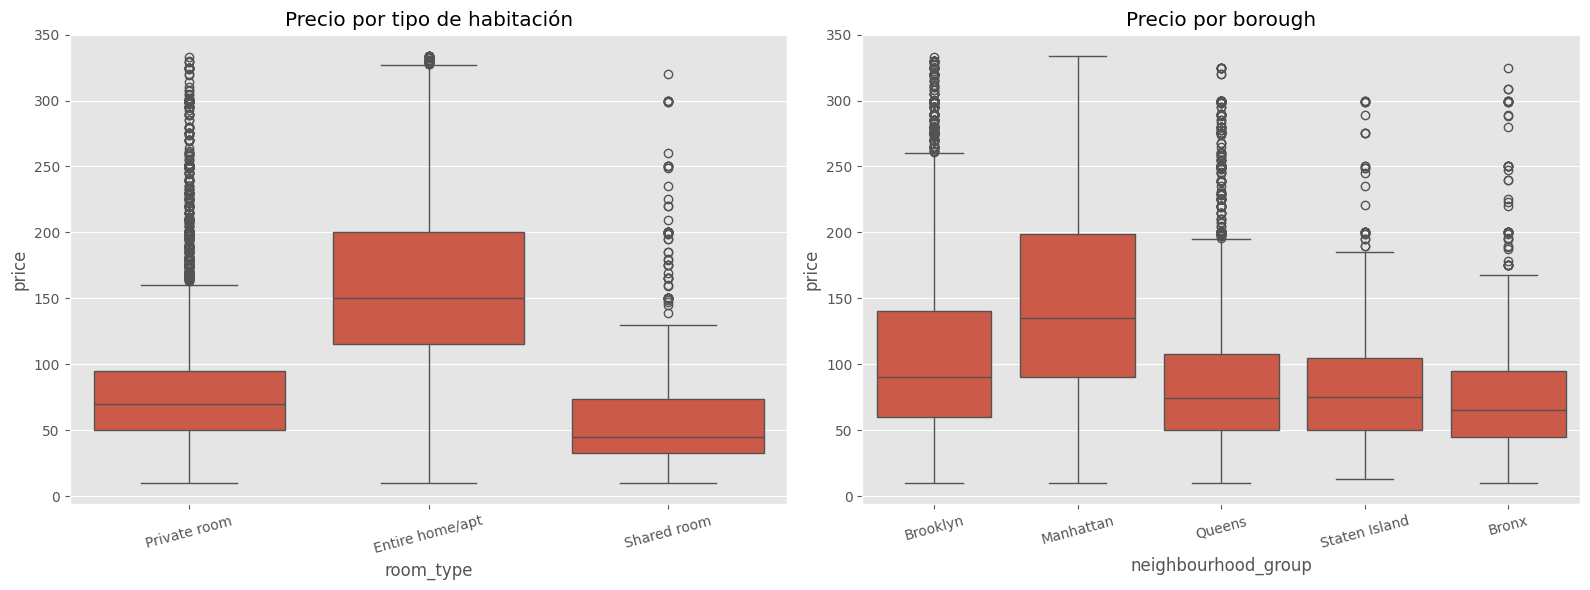

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precio por room_type
sns.boxplot(data=df, x="room_type", y="price", ax=axes[0])
axes[0].set_title("Precio por tipo de habitación")
axes[0].tick_params(axis='x', rotation=15)

# Precio por borough
sns.boxplot(data=df, x="neighbourhood_group", y="price", ax=axes[1])
axes[1].set_title("Precio por borough")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

room_type explica más la variación de precio que el borough. Un Entire home/apt en el Bronx puede costar más que un Private room en Manhattan.

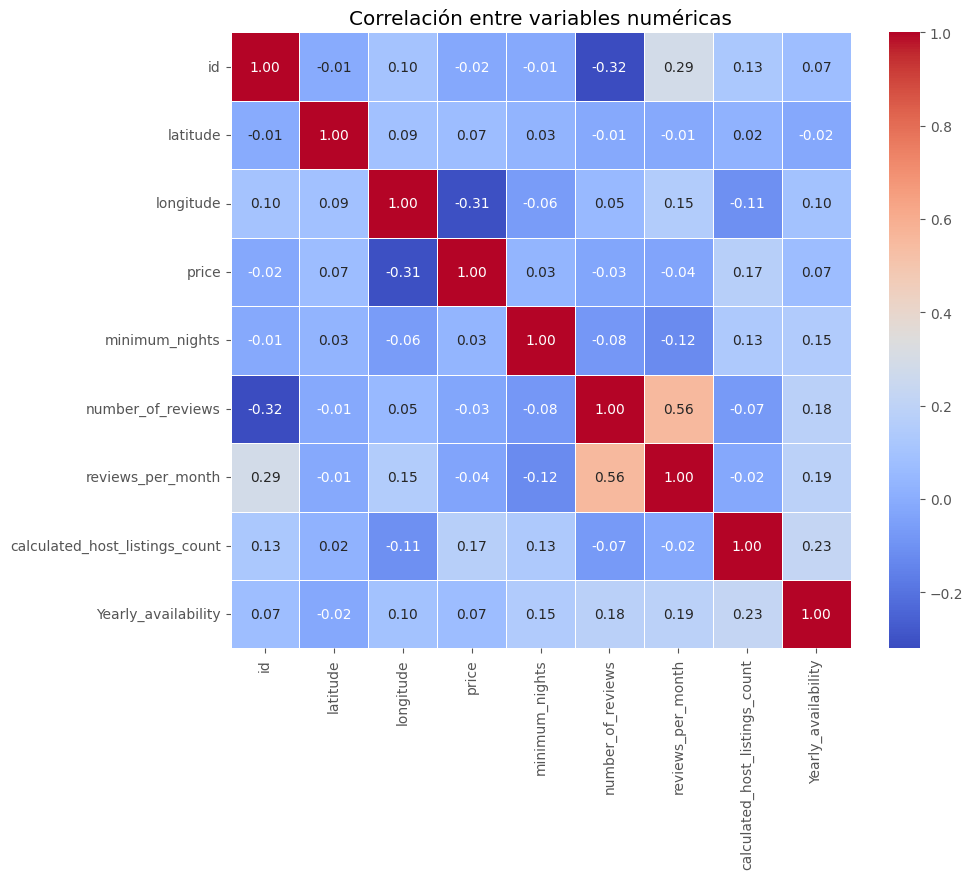

In [113]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True), 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlación entre variables numéricas")
plt.show()

Las variables numéricas solas no predicen bien el precio. Las variables categóricas (room_type, neighbourhood_group) son mucho más importantes — eso explica por qué los boxplots del Paso 2 fueron más informativos que este heatmap.

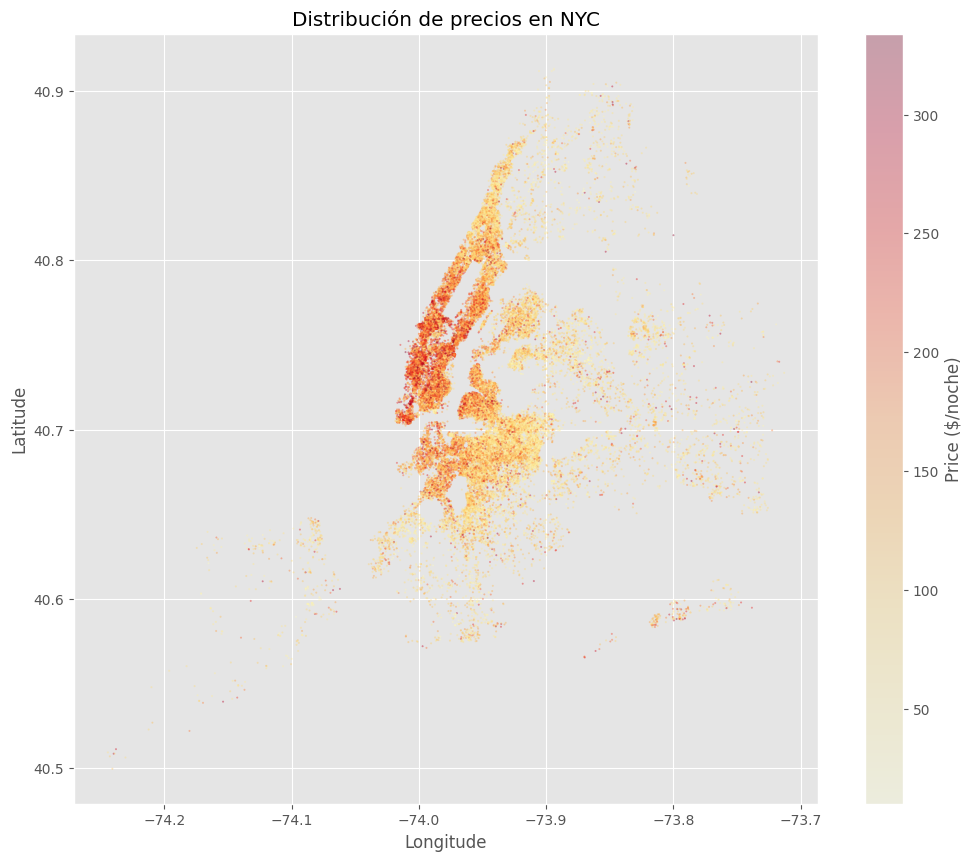

In [114]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    df["longitude"], df["latitude"],
    c=df["price"], cmap="YlOrRd",
    alpha=0.3, s=1
)
plt.colorbar(scatter, label="Price ($/noche)")
plt.title("Distribución de precios en NYC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Manhattan es el área más cara y densa de listings, visible como la franja roja en el mapa. Brooklyn y Queens son más accesibles en precio y están justo al lado. El Bronx y Staten Island tienen muy pocos listings y precios bajos. En general, mientras más cerca estés del centro de Manhattan, más caro es el Airbnb, la ubicación lo es todo en NYC.

# Conclusiones EDA — Airbnb NYC 2019

## 1. Precios
La mayoría de los listings tienen un precio de entre $50 y $150 por noche, con una mediana de ~$100. Los precios siguen una distribución sesgada a la derecha, con algunos listings outliers que fueron removidos durante la limpieza de datos.

## 2. Tipo de habitación
El tipo de habitación es uno de los factores más importantes en el precio. Los apartamentos completos (`Entire home/apt`) tienen una mediana de ~$150/noche, casi el doble que las habitaciones privadas (~$70). Los cuartos compartidos son los más baratos pero representan menos del 5% del mercado.

## 3. Ubicación
Manhattan es el borough más caro con una mediana de ~$135/noche y la mayor concentración de listings. Brooklyn tiene precios intermedios (~$90) y una oferta similar a Manhattan. Queens, el Bronx y Staten Island son opciones más económicas, con medianas alrededor de los $70/noche.

## 4. Tipo de host
Los hosts profesionales (6+ propiedades) cobran en promedio $180/noche, mientras que los hosts casuales (2-5 propiedades) cobran $125. Los hosts con una sola propiedad se ubican en el medio con ~$158, posiblemente porque algunas de esas propiedades son premium.

## 5. Correlaciones
Las variables numéricas tienen una correlación baja con el precio. La longitud geográfica es la variable con mayor correlación (-0.31), reflejando que Manhattan (más al oeste) es más caro. Las variables categóricas como `room_type` y `neighbourhood_group` son mejores predictores del precio.

## 6. Calidad de los datos
Se identificaron y removieron ~3,000 listings con precios outliers (por encima de $334/noche según el método IQR), además de 11 listings con precio $0. También se rellenaron los valores nulos de `reviews_per_month` con 0, correspondientes a propiedades sin reseñas.


In [115]:

train, test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (36729, 13)
Test: (9183, 13)


In [116]:
os.makedirs("./data/processed", exist_ok=True)

train.to_csv("./data/processed/train.csv", index=False)
test.to_csv("./data/processed/test.csv", index=False)

In [117]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv"
response = requests.get(url)

os.makedirs("./data/raw", exist_ok=True)
with open("./data/raw/AB_NYC_2019.csv", "wb") as f:
    f.write(response.content)

In [118]:
# Convertir columnas categóricas a numéricas
train_model = pd.get_dummies(train, columns=["room_type", "neighbourhood_group", "host_type"], drop_first=True)
test_model = pd.get_dummies(test, columns=["room_type", "neighbourhood_group", "host_type"], drop_first=True)

train_model, test_model = train_model.align(test_model, join="left", axis=1, fill_value=0)

X_train = train_model.drop(columns=["price"])
y_train = train_model["price"]

X_test = test_model.drop(columns=["price"])
y_test = test_model["price"]

print(X_train.shape)

(36729, 17)


In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: ${rmse:.2f}")
print(f"R²: {r2:.4f}")

RMSE: $46.25
R²: 0.5275


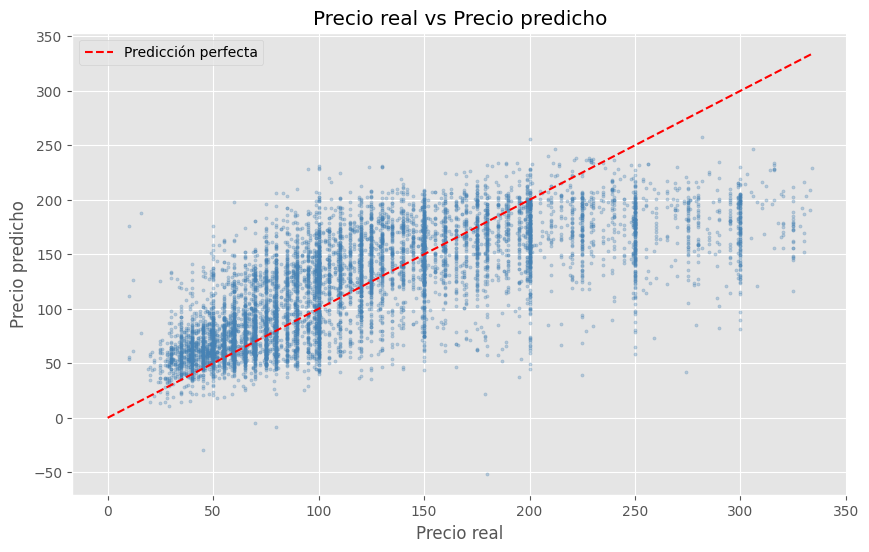

In [124]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=5, color="steelblue")
plt.plot([0, 334], [0, 334], color="red", linewidth=1.5, linestyle="--", label="Predicción perfecta")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Precio real vs Precio predicho")
plt.legend()
plt.show()

Funciona bien para propiedades económicas pero pierde precisión en propiedades caras. Esto es esperado dado que  la regresión lineal asume una relación constante entre variables y precio, pero en Airbnb esa relación no es lineal.

## Conclusiones del Modelo

- **RMSE: $46.25** — el modelo se equivoca ~$46 por noche en promedio
- **R²: 0.5275** — explica el 52% de la variación de precios
- Funciona bien en precios bajos ($0-$150) pero subestima precios altos
- Las variables más importantes fueron `room_type` y `neighbourhood`

In [127]:
os.makedirs("./models", exist_ok=True)
with open("./models/linear_regression.pkl", "wb") as f:
    pickle.dump(model, f)